# Basic Battery Thermal Simulation

Simulating battery temperature over time using a simple heat balance model.

**Heat in (I²R) − Heat out (cooling) = Temperature change**

First test on made-up current profiles, then plug in real cycle data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, glob
from sklearn.metrics import mean_squared_error

## The Thermal Model

At every time step:
- battery generates heat from current flowing through internal resistance → `Q_gen = I² × R`
- battery loses heat to surroundings → `Q_loss = hA × (T - T_amb)`
- net change in temperature → `dT = (Q_gen - Q_loss) × dt / (m × Cp)`

In [2]:
def run_thermal_model(current, time, R=0.01, hA=0.1, mass=0.045, Cp=900, T_amb=25):
    # R    = internal resistance (Ohm)
    # hA   = cooling coefficient (W/K) — higher means better cooling
    # mass = battery mass in kg
    # Cp   = specific heat capacity J/(kg.K)
    # T_amb = ambient/starting temperature

    temps = np.zeros(len(time))
    temps[0] = T_amb

    dt = np.mean(np.diff(time))  # assume roughly uniform time steps

    for i in range(1, len(time)):
        Q_gen  = (current[i] ** 2) * R          # joule heating
        Q_loss = hA * (temps[i-1] - T_amb)      # heat lost to surroundings
        dT = (Q_gen - Q_loss) * dt / (mass * Cp)
        temps[i] = temps[i-1] + dT

    return temps

## Test on Synthetic Profiles

Testing with constant and pulsed loads first — just to make sure the model behaves correctly before using real data.

In [3]:
# 10 minutes, 1s steps
t = np.arange(0, 600, 1)

test_profiles = {
    "Low (10A)":    np.ones_like(t) * 10,
    "Medium (30A)": np.ones_like(t) * 30,
    "High (50A)":   np.ones_like(t) * 50,
    "Pulsed (40A)": np.where((t % 60) < 30, 40, 0)  # on/off every 30s
}

hA_vals = [0.05, 0.1, 0.2]  # weak / medium / strong cooling

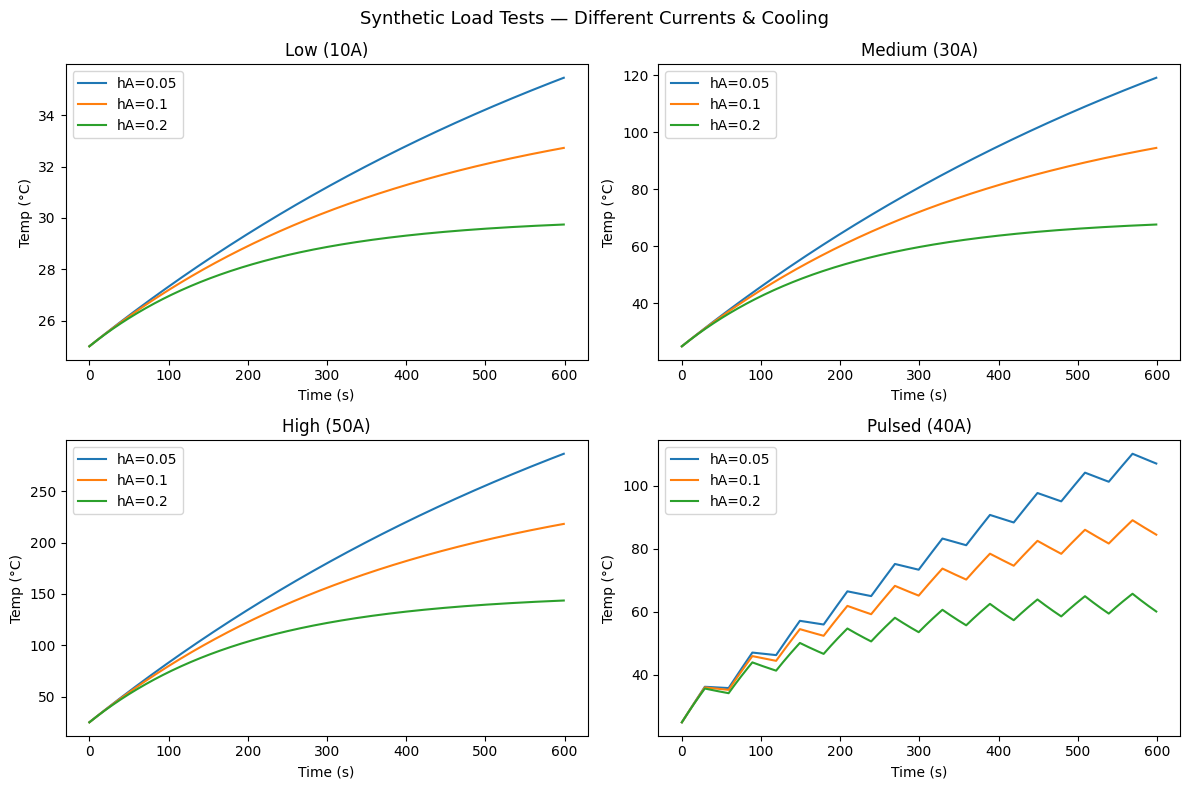

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (label, I_profile) in enumerate(test_profiles.items()):
    ax = axes[idx]
    for hA in hA_vals:
        T_sim = run_thermal_model(I_profile, t, hA=hA)
        ax.plot(t, T_sim, label=f"hA={hA}")
    ax.set_title(label)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Temp (°C)")
    ax.legend()

plt.suptitle("Synthetic Load Tests — Different Currents & Cooling", fontsize=13)
plt.tight_layout()
plt.show()

## Apply to Real Cycle Data (Cycle 10)

Load one discharge cycle from the processed dataset and compare simulated vs measured temperature.

In [5]:
df_c10 = pd.read_csv("../data/processed/B0005_cycle_10.csv")

t_real   = df_c10["time_s"].values
I_real   = df_c10["current_A"].values
T_meas   = df_c10["temp_C"].values
T_start  = T_meas[0]  # use first measured temp as starting point

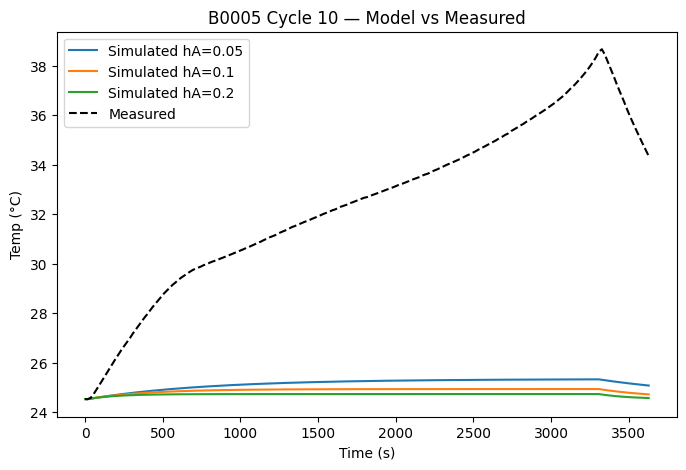

In [6]:
plt.figure(figsize=(8, 5))

for hA in hA_vals:
    T_sim = run_thermal_model(I_real, t_real, hA=hA, T_amb=T_start)
    plt.plot(t_real, T_sim, label=f"Simulated hA={hA}")

plt.plot(t_real, T_meas, 'k--', label="Measured")  # actual sensor data

plt.xlabel("Time (s)")
plt.ylabel("Temp (°C)")
plt.title("B0005 Cycle 10 — Model vs Measured")
plt.legend()
plt.show()

## Check Accuracy with RMSE — Early / Mid / Late Cycles

Picking three cycles across the battery's lifetime to see if model accuracy changes as battery degrades.

In [7]:
def plot_cycle_comparison(cycle_num, hA_list=[0.05, 0.1, 0.2]):
    path = f"../data/processed/B0005_cycle_{cycle_num}.csv"
    if not os.path.exists(path):
        print(f"Cycle {cycle_num} not found, skipping")
        return

    df = pd.read_csv(path)
    time  = df["time_s"].values
    I     = df["current_A"].values
    T_ref = df["temp_C"].values
    T0    = T_ref[0]

    plt.figure(figsize=(8, 5))

    for hA in hA_list:
        T_sim = run_thermal_model(I, time, hA=hA, T_amb=T0)
        rmse = np.sqrt(mean_squared_error(T_ref, T_sim))
        plt.plot(time, T_sim, label=f"hA={hA}  RMSE={rmse:.2f}°C")

    plt.plot(time, T_ref, 'k--', label="Measured")
    plt.xlabel("Time (s)")
    plt.ylabel("Temp (°C)")
    plt.title(f"Cycle {cycle_num} — Simulated vs Measured")
    plt.legend()
    plt.show()

Cycles chosen: [2, 294, 614]


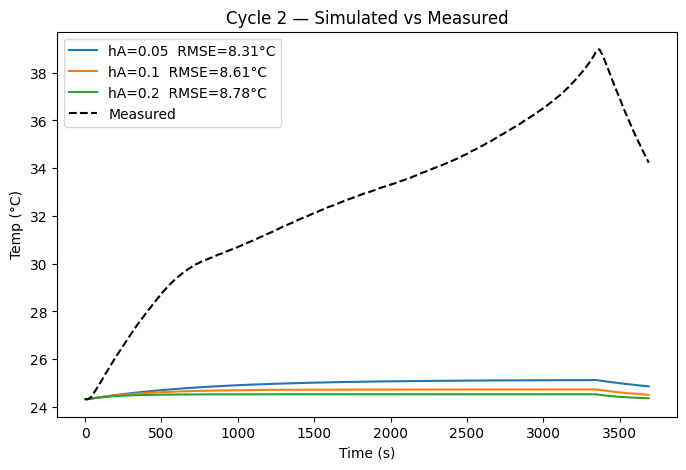

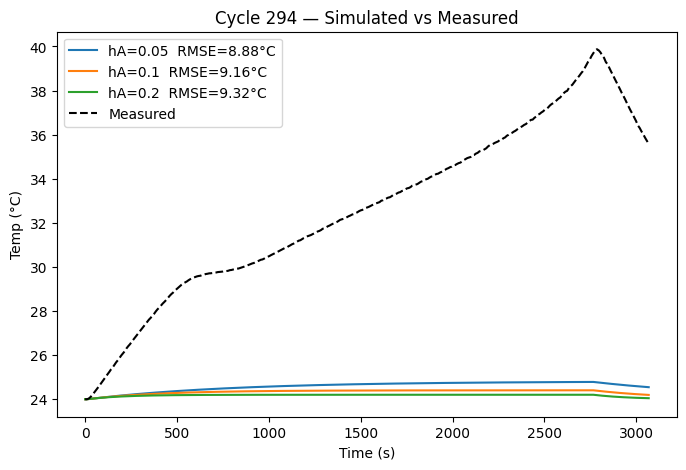

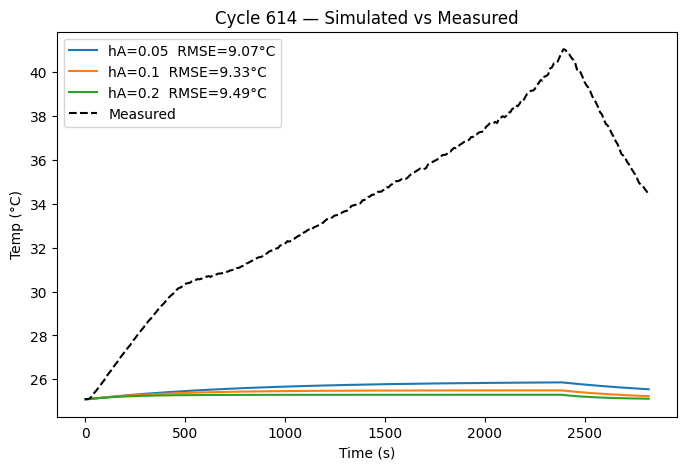

In [8]:
cycle_files = glob.glob("../data/processed/B0005_cycle_*.csv")
all_cycles = sorted([int(f.split("_")[-1].split(".")[0]) for f in cycle_files])

# pick one from start, middle and end
chosen = [all_cycles[0], all_cycles[len(all_cycles)//2], all_cycles[-1]]
print("Cycles chosen:", chosen)

for c in chosen:
    plot_cycle_comparison(c)

## RMSE Over All Cycles

Running the model on every cycle with fixed hA=0.1 and plotting how the error changes — if it goes up over time, the fixed-parameter model isn't keeping up with battery aging.

In [9]:
hA_fixed = 0.1
R_fixed  = 0.01

results = []

for c in all_cycles:
    df = pd.read_csv(f"../data/processed/B0005_cycle_{c}.csv")

    time  = df["time_s"].values
    I     = df["current_A"].values
    T_ref = df["temp_C"].values

    T_sim = run_thermal_model(I, time, R=R_fixed, hA=hA_fixed, T_amb=T_ref[0])
    rmse  = np.sqrt(mean_squared_error(T_ref, T_sim))

    results.append({"cycle": c, "rmse": rmse})

df_results = pd.DataFrame(results)

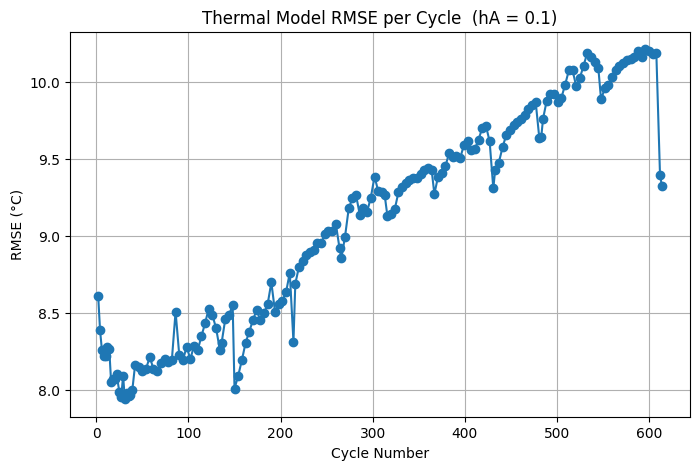

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["cycle"], df_results["rmse"], marker="o")
plt.xlabel("Cycle Number")
plt.ylabel("RMSE (°C)")
plt.title(f"Thermal Model RMSE per Cycle  (hA = {hA_fixed})")
plt.grid(True)
plt.show()